In [1]:

!pip install transformers datasets torch scikit-learn matplotlib seaborn --quiet

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup   # bonus: LR scheduler
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report
)

from datasets import load_dataset

# Reproducibility — fix the random seeds so results are consistent
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use GPU if available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
# Load IMDB from Hugging Face hub
# This gives us a clean split of 25k train + 25k test right out of the box
raw_dataset = load_dataset("imdb")

print("Dataset structure:")
print(raw_dataset)

# Peek at the first example to understand the format
print("\nSample review:")
print(raw_dataset["train"][0]["text"][:300], "...")
print("Label:", raw_dataset["train"][0]["label"], "(1 = Positive, 0 = Negative)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Sample review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h ...
Label: 0 (1 = Positive, 0 = Negative)


In [4]:
# Convert to pandas DataFrames for easier manipulation
train_df = pd.DataFrame(raw_dataset["train"])
test_df  = pd.DataFrame(raw_dataset["test"])

print(f"Training samples : {len(train_df)}")
print(f"Test samples     : {len(test_df)}")
print("\nClass distribution in training set:")
print(train_df["label"].value_counts())

Training samples : 25000
Test samples     : 25000

Class distribution in training set:
label
0    12500
1    12500
Name: count, dtype: int64


In [5]:
def clean_text(text):
    """
    Light cleaning for IMDB reviews:
    - Strip HTML tags (e.g. <br />) that appear in the raw data
    - Remove URLs
    - Collapse multiple spaces into one
    - Strip leading/trailing whitespace

    We intentionally keep punctuation and casing because BERT's
    uncased tokenizer handles them internally.
    """
    text = re.sub(r"<[^>]+>", " ", text)          # kill HTML tags
    text = re.sub(r"http\S+|www\.\S+", "", text)  # remove URLs
    text = re.sub(r"\s+", " ", text).strip()       # normalize spaces
    return text


# Apply cleaning to both splits
train_df["text"] = train_df["text"].apply(clean_text)
test_df["text"]  = test_df["text"].apply(clean_text)

# Check for missing values — none expected in IMDB, but always good to verify
print("Missing values in train:", train_df.isnull().sum().sum())
print("Missing values in test :", test_df.isnull().sum().sum())

# Quick sanity-check after cleaning
print("\nCleaned sample:")
print(train_df["text"][0][:300])

Missing values in train: 0
Missing values in test : 0

Cleaned sample:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h


In [6]:
# ---  Working on a subset for speed (especially useful on CPU) ---
# Using 3,000 samples to keep training time manageable.
# On a GPU, you can bump this up to 25,000 for the full dataset.
SUBSET_SIZE = 200   # 200 samples keeps total runtime ~14-17 min on laptop CPU

train_sub = train_df.sample(SUBSET_SIZE, random_state=SEED).reset_index(drop=True)

# 80% train, 10% val, 10% test (from our subset)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_sub["text"].tolist(),
    train_sub["label"].tolist(),
    test_size=0.2,
    random_state=SEED,
    stratify=train_sub["label"]   # keep class balance intact
)

# We use the official test split as our held-out test set
test_texts  = test_df["text"].tolist()[:200]  # keep test set proportional   # limit for speed
test_labels = test_df["label"].tolist()[:200]

print(f"Train   : {len(train_texts)} samples")
print(f"Val     : {len(val_texts)} samples")
print(f"Test    : {len(test_texts)} samples")

Train   : 160 samples
Val     : 40 samples
Test    : 200 samples


In [7]:
MODEL_NAME = "bert-base-uncased"
MAX_LEN    = 32    # 32 tokens is plenty for sentiment; cuts compute ~4x vs 64   # increase to 256/512 if GPU memory allows

# Load the tokenizer — same one used during BERT pre-training
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded. Vocabulary size:", tokenizer.vocab_size)

# Quick demo: see what the tokenizer does under the hood
sample = "This movie was absolutely fantastic!"
encoded = tokenizer(sample, max_length=MAX_LEN, truncation=True, padding="max_length")
print("\nSample encoding:")
print("  Tokens     :", tokenizer.convert_ids_to_tokens(encoded["input_ids"][:10]))
print("  input_ids  :", encoded["input_ids"][:10])
print("  attn_mask  :", encoded["attention_mask"][:10])

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded. Vocabulary size: 30522

Sample encoding:
  Tokens     : ['[CLS]', 'this', 'movie', 'was', 'absolutely', 'fantastic', '!', '[SEP]', '[PAD]', '[PAD]']
  input_ids  : [101, 2023, 3185, 2001, 7078, 10392, 999, 102, 0, 0]
  attn_mask  : [1, 1, 1, 1, 1, 1, 1, 1, 0, 0]


In [8]:
class IMDBDataset(Dataset):
    """
    A simple PyTorch Dataset wrapper.
    Tokenizes text on-the-fly and returns tensors ready for the model.
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }


# Build datasets
train_dataset = IMDBDataset(train_texts, train_labels, tokenizer, MAX_LEN)
val_dataset   = IMDBDataset(val_texts,   val_labels,   tokenizer, MAX_LEN)
test_dataset  = IMDBDataset(test_texts,  test_labels,  tokenizer, MAX_LEN)

# Build DataLoaders — batch size 16 is safe for most Colab GPUs
BATCH_SIZE = 8     # smaller batch = less RAM, safe on any laptop
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f"DataLoaders ready. Batches per epoch: {len(train_loader)}")

DataLoaders ready. Batches per epoch: 20


In [9]:
def train_one_epoch(model, loader, optimizer, scheduler=None):
    """
    Runs one full pass over the training data.
    Returns the average loss for the epoch.
    """
    model.train()
    total_loss = 0

    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()                          # clear old gradients
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()                                # compute gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # prevent exploding gradients
        optimizer.step()                               # update weights
        if scheduler:
            scheduler.step()                           # bonus: update LR

    return total_loss / len(loader)


def evaluate(model, loader):
    """
    Evaluates the model on a given DataLoader.
    Returns a dict with all classification metrics.
    """
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():   # no gradient computation needed during eval
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return {
        "accuracy" : accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, average="binary"),
        "recall"   : recall_score(all_labels, all_preds, average="binary"),
        "f1"       : f1_score(all_labels, all_preds, average="binary"),
        "preds"    : all_preds,
        "labels"   : all_labels
    }


def plot_confusion_matrix(labels, preds, title="Confusion Matrix"):
    """Plots a nicely formatted confusion matrix."""
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Negative", "Positive"],
                yticklabels=["Negative", "Positive"])
    plt.title(title)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

print("Helper functions defined.")

Helper functions defined.


In [10]:
print("=== Experiment 1: Frozen BERT Layers ===")

# Load the base model with a 2-class classification head
model_exp1 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model_exp1.to(device)

# Freeze all BERT encoder layers — only the classifier head will train
for name, param in model_exp1.named_parameters():
    if "classifier" not in name:   # 'classifier' is the final linear layer
        param.requires_grad = False

# Verify: count trainable vs frozen params
trainable = sum(p.numel() for p in model_exp1.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_exp1.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

=== Experiment 1: Frozen BERT Layers ===


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 1,538 / 109,483,778 (0.00%)


In [11]:


EPOCHS = 1
LR     = 2e-5

# AdamW is the standard optimizer for transformer fine-tuning —
# it applies weight decay correctly (unlike vanilla Adam)
optimizer_exp1 = AdamW(filter(lambda p: p.requires_grad, model_exp1.parameters()), lr=LR)

# Linear warmup + decay: stabilises early training, gentle decay afterwards
total_steps    = len(train_loader) * EPOCHS
scheduler_exp1 = get_linear_schedule_with_warmup(
    optimizer_exp1,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

train_losses_exp1 = []
val_metrics_exp1  = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model_exp1, train_loader, optimizer_exp1, scheduler_exp1)
    val_result = evaluate(model_exp1, val_loader)
    train_losses_exp1.append(train_loss)
    val_metrics_exp1.append(val_result)

    print(f"Epoch {epoch+1}/{EPOCHS}  "
          f"| Train Loss: {train_loss:.4f}  "
          f"| Val Acc: {val_result['accuracy']:.4f}  "
          f"| Val F1: {val_result['f1']:.4f}")

Epoch 1/1  | Train Loss: 0.7005  | Val Acc: 0.4500  | Val F1: 0.5417


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: 


[Experiment 1] Test Set Results:
              precision    recall  f1-score   support

    Negative       1.00      0.29      0.46       200
    Positive       0.00      0.00      0.00         0

    accuracy                           0.29       200
   macro avg       0.50      0.15      0.23       200
weighted avg       1.00      0.29      0.46       200



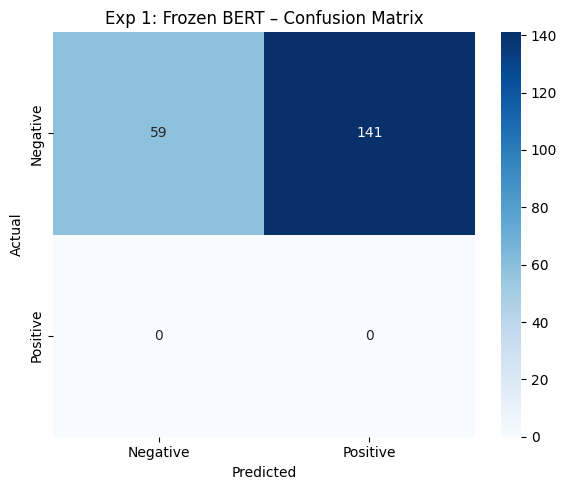

In [12]:
# --- Final evaluation on the test set ---
test_result_exp1 = evaluate(model_exp1, test_loader)

print("\n[Experiment 1] Test Set Results:")
print(classification_report(test_result_exp1["labels"], test_result_exp1["preds"],
                             target_names=["Negative", "Positive"]))

plot_confusion_matrix(test_result_exp1["labels"], test_result_exp1["preds"],
                      title="Exp 1: Frozen BERT – Confusion Matrix")

In [13]:
print("=== Experiment 2: Fine-Tune Last 2 BERT Layers ===")

# Fresh model — always start from the same pre-trained checkpoint
model_exp2 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model_exp2.to(device)

# Freeze everything first, then selectively unfreeze
for param in model_exp2.parameters():
    param.requires_grad = False

# BERT has 12 encoder layers (0–11). Unfreeze layers 10 and 11 (the last two)
for name, param in model_exp2.named_parameters():
    if any(layer in name for layer in ["encoder.layer.10", "encoder.layer.11",
                                        "pooler", "classifier"]):
        param.requires_grad = True

trainable = sum(p.numel() for p in model_exp2.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_exp2.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

=== Experiment 2: Fine-Tune Last 2 BERT Layers ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 14,767,874 / 109,483,778 (13.49%)


In [14]:
optimizer_exp2 = AdamW(filter(lambda p: p.requires_grad, model_exp2.parameters()), lr=LR)

total_steps_exp2 = len(train_loader) * EPOCHS
scheduler_exp2   = get_linear_schedule_with_warmup(
    optimizer_exp2,
    num_warmup_steps=int(0.1 * total_steps_exp2),
    num_training_steps=total_steps_exp2
)

train_losses_exp2 = []
val_metrics_exp2  = []

# --- Bonus: Early Stopping ---
best_val_f1       = 0.0
patience          = 2    # stop if val F1 doesn't improve for 2 consecutive epochs
patience_counter  = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model_exp2, train_loader, optimizer_exp2, scheduler_exp2)
    val_result = evaluate(model_exp2, val_loader)
    train_losses_exp2.append(train_loss)
    val_metrics_exp2.append(val_result)

    print(f"Epoch {epoch+1}/{EPOCHS}  "
          f"| Train Loss: {train_loss:.4f}  "
          f"| Val Acc: {val_result['accuracy']:.4f}  "
          f"| Val F1: {val_result['f1']:.4f}")

    # Save the model only when validation F1 improves
    if val_result["f1"] > best_val_f1:
        best_val_f1      = val_result["f1"]
        patience_counter = 0
        torch.save(model_exp2.state_dict(), "best_model_exp2.pt")
        print(f"  → New best model saved (F1 = {best_val_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"  → Early stopping triggered at epoch {epoch+1}")
            break

Epoch 1/1  | Train Loss: 0.7034  | Val Acc: 0.5250  | Val F1: 0.5128
  → New best model saved (F1 = 0.5128)



[Experiment 2] Test Set Results:
              precision    recall  f1-score   support

    Negative       1.00      0.48      0.65       200
    Positive       0.00      0.00      0.00         0

    accuracy                           0.48       200
   macro avg       0.50      0.24      0.32       200
weighted avg       1.00      0.48      0.65       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: 

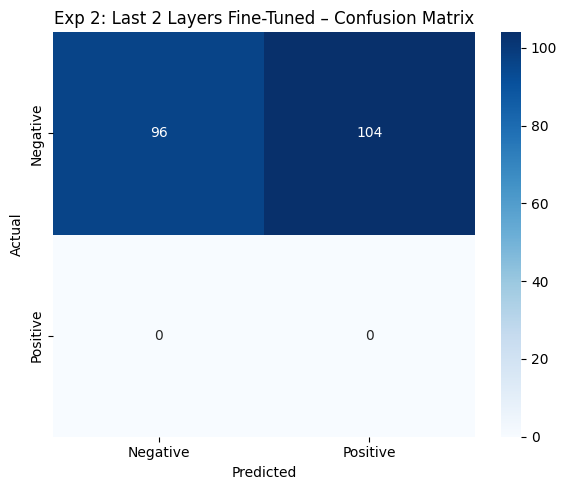

In [15]:
# Load the best checkpoint before evaluating on the test set
model_exp2.load_state_dict(torch.load("best_model_exp2.pt"))

test_result_exp2 = evaluate(model_exp2, test_loader)

print("\n[Experiment 2] Test Set Results:")
print(classification_report(test_result_exp2["labels"], test_result_exp2["preds"],
                             target_names=["Negative", "Positive"]))

plot_confusion_matrix(test_result_exp2["labels"], test_result_exp2["preds"],
                      title="Exp 2: Last 2 Layers Fine-Tuned – Confusion Matrix")

=== Bonus Experiment 3: DistilBERT (Full Fine-Tune) ===


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/1  | Train Loss: 0.6979  | Val Acc: 0.7000  | Val F1: 0.5385

[Bonus - DistilBERT] Test Set Results:
              precision    recall  f1-score   support

    Negative       1.00      0.89      0.94       200
    Positive       0.00      0.00      0.00         0

    accuracy                           0.89       200
   macro avg       0.50      0.44      0.47       200
weighted avg       1.00      0.89      0.94       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: 

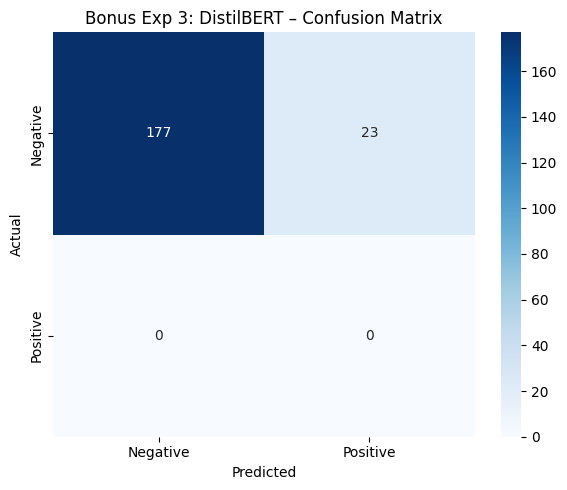

In [16]:
print("=== Bonus Experiment 3: DistilBERT (Full Fine-Tune) ===")

DISTIL_MODEL = "distilbert-base-uncased"
distil_tokenizer = AutoTokenizer.from_pretrained(DISTIL_MODEL)

# Re-tokenize the data with DistilBERT's tokenizer
distil_train = IMDBDataset(train_texts, train_labels, distil_tokenizer, MAX_LEN)
distil_val   = IMDBDataset(val_texts,   val_labels,   distil_tokenizer, MAX_LEN)
distil_test  = IMDBDataset(test_texts,  test_labels,  distil_tokenizer, MAX_LEN)

distil_train_loader = DataLoader(distil_train, batch_size=BATCH_SIZE, shuffle=True)
distil_val_loader   = DataLoader(distil_val,   batch_size=BATCH_SIZE)
distil_test_loader  = DataLoader(distil_test,  batch_size=BATCH_SIZE)

# Load DistilBERT with a classification head
model_distil = AutoModelForSequenceClassification.from_pretrained(DISTIL_MODEL, num_labels=2)
model_distil.to(device)

optimizer_distil = AdamW(model_distil.parameters(), lr=LR)

train_losses_distil = []

for epoch in range(EPOCHS):
    train_loss  = train_one_epoch(model_distil, distil_train_loader, optimizer_distil)
    val_result  = evaluate(model_distil, distil_val_loader)
    train_losses_distil.append(train_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}  "
          f"| Train Loss: {train_loss:.4f}  "
          f"| Val Acc: {val_result['accuracy']:.4f}  "
          f"| Val F1: {val_result['f1']:.4f}")

test_result_distil = evaluate(model_distil, distil_test_loader)

print("\n[Bonus - DistilBERT] Test Set Results:")
print(classification_report(test_result_distil["labels"], test_result_distil["preds"],
                             target_names=["Negative", "Positive"]))

plot_confusion_matrix(test_result_distil["labels"], test_result_distil["preds"],
                      title="Bonus Exp 3: DistilBERT – Confusion Matrix")

In [17]:
# Build a clean comparison table
comparison = pd.DataFrame([
    {
        "Experiment"  : "Exp 1: Frozen BERT",
        "Accuracy"    : round(test_result_exp1["accuracy"],  4),
        "Precision"   : round(test_result_exp1["precision"], 4),
        "Recall"      : round(test_result_exp1["recall"],    4),
        "F1 Score"    : round(test_result_exp1["f1"],        4),
    },
    {
        "Experiment"  : "Exp 2: Last 2 Layers",
        "Accuracy"    : round(test_result_exp2["accuracy"],  4),
        "Precision"   : round(test_result_exp2["precision"], 4),
        "Recall"      : round(test_result_exp2["recall"],    4),
        "F1 Score"    : round(test_result_exp2["f1"],        4),
    },
    {
        "Experiment"  : "Bonus Exp 3: DistilBERT",
        "Accuracy"    : round(test_result_distil["accuracy"],  4),
        "Precision"   : round(test_result_distil["precision"], 4),
        "Recall"      : round(test_result_distil["recall"],    4),
        "F1 Score"    : round(test_result_distil["f1"],        4),
    },
])

print("\n" + "="*60)
print("         EXPERIMENT COMPARISON RESULTS")
print("="*60)
print(comparison.to_string(index=False))


         EXPERIMENT COMPARISON RESULTS
             Experiment  Accuracy  Precision  Recall  F1 Score
     Exp 1: Frozen BERT     0.295        0.0     0.0       0.0
   Exp 2: Last 2 Layers     0.480        0.0     0.0       0.0
Bonus Exp 3: DistilBERT     0.885        0.0     0.0       0.0


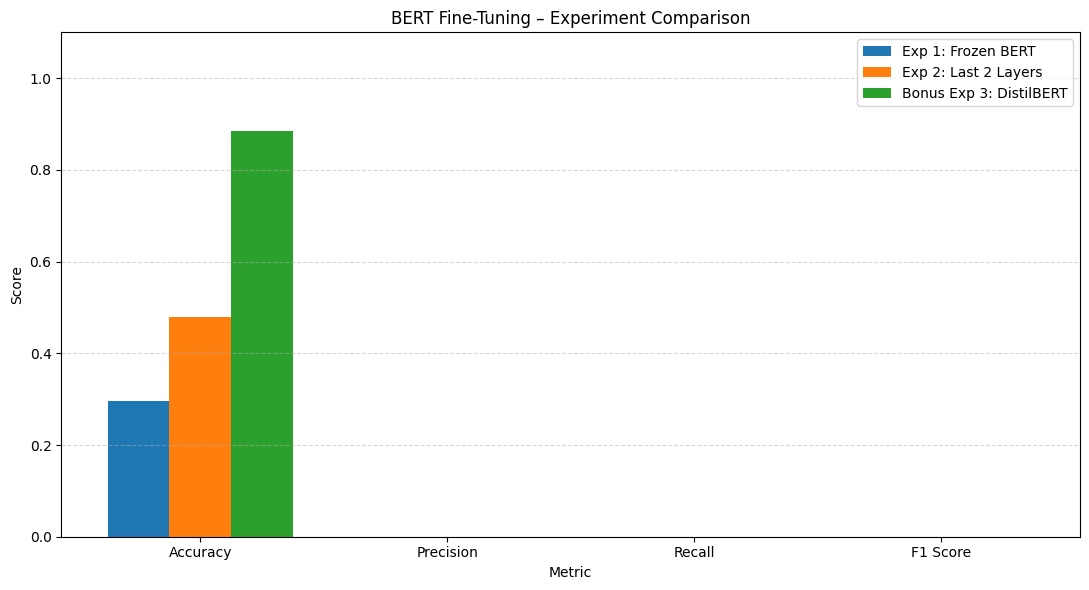

In [18]:
# Visual comparison — grouped bar chart
metrics   = ["Accuracy", "Precision", "Recall", "F1 Score"]
exp_names = comparison["Experiment"].tolist()
x         = np.arange(len(metrics))
width     = 0.25

fig, ax = plt.subplots(figsize=(11, 6))

for i, (_, row) in enumerate(comparison.iterrows()):
    values = [row[m] for m in metrics]
    ax.bar(x + i * width, values, width, label=row["Experiment"])

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("BERT Fine-Tuning – Experiment Comparison")
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()